**Classification Hands-on (Training + Evaluation Demo)**

Dataset: Pima Indians Diabetes (diabetes.csv)

Goal: Keep it simple and focus on:
1) Training Logistic Regression
2) Evaluating with metrics + ROC AUC

**1. Setup**

In [1]:
# installing the dependencies
%pip install numpy pandas matplotlib seaborn scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


**2. Load Data**

Keep `daiabetes.csv` in the same folder as this notebook file

In [3]:
df = pd.read_csv("diabetes.csv")

In [4]:
df.shape

(768, 9)

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**⚕️ Pima Indians Diabetes Dataset**

| Column Name | Description |
|------------|-------------|
| Pregnancies | Number of times the patient has been pregnant |
| Glucose | Plasma glucose concentration after 2 hours in an oral glucose tolerance test |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Thickness of the triceps skin fold (mm) |
| Insulin | 2 hour serum insulin level (mu U/ml) |
| BMI | Body Mass Index (weight in kg / height in m²) |
| DiabetesPedigreeFunction | Likelihood of diabetes based on family history |
| Age | Age of the patient in years |
| Outcome | Target variable indicating diabetes status (1 = Diabetic, 0 = Non Diabetic) |

**3. Quick checks (high-level)**

We are not doing deep EDA / preprocessing for this video

In [7]:
# missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [9]:
df["Outcome"].value_counts(normalize=True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

**4. Split features and target**

In [10]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [11]:
X[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [12]:
y[:5]

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

**5. Train Test Split**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X shape: (768, 8)
X_train shape: (614, 8)
X_test shape: (154, 8)


**6. Scale the features**

Fit scaler only on training data, then transform both training and test data

In [15]:
scaler = StandardScaler()

In [16]:
X_train_scaled = scaler.fit_transform(X_train)  # fit & transform
X_test_scaled = scaler.transform(X_test)

**7. Model Training (Logistic Regression)**

In [17]:
model = LogisticRegression()

In [18]:
# training the model
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


**8. Predictions**

In [19]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

In [20]:
X_train_scaled[:3]

array([[-0.85135507, -0.98013068, -0.40478372, -0.55397256, -0.33131928,
        -0.60767846,  0.31079384, -0.79216928],
       [ 0.35657564,  0.16144422,  0.46536842,  0.392787  , -0.52639809,
        -0.30213902, -0.11643851,  0.56103382],
       [-0.5493724 , -0.50447447, -0.62232176,  1.21331196,  0.14244354,
         0.3725939 , -0.76486207, -0.70759409]])

In [21]:
y_train[:3]

353    0
711    0
373    0
Name: Outcome, dtype: int64

In [22]:
y_train_pred[:3]

array([0, 0, 0])

In [23]:
y_test_pred[:3]

array([1, 0, 0])

In [24]:
y_test_prob[:3]

array([0.61667353, 0.11278116, 0.27253958])

**9. Evaluation Metric (Train & Test)**

In [25]:
def print_metrics(title, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)   # (test_labels, prediction_labels)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(title)
    print(f"  Accuracy: {acc:.2%}")
    print(f"  Precision: {prec:.2%}")
    print(f"  Recall: {rec:.2%}")
    print(f"  F1-score: {f1:.2%}")

In [26]:
print_metrics("TRAIN METRICS", y_train, y_train_pred)
print_metrics("TEST METRICS", y_test, y_test_pred)

TRAIN METRICS
  Accuracy: 79.15%
  Precision: 75.90%
  Recall: 58.88%
  F1-score: 66.32%
TEST METRICS
  Accuracy: 71.43%
  Precision: 60.87%
  Recall: 51.85%
  F1-score: 56.00%


Confusion Matrix
[[82 18]
 [26 28]]


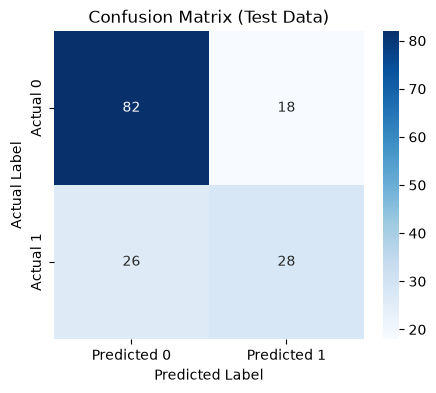

In [27]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Test Data)")
plt.show()

**9. ROC Curve + AUC**

ROC AUC Score: 0.823


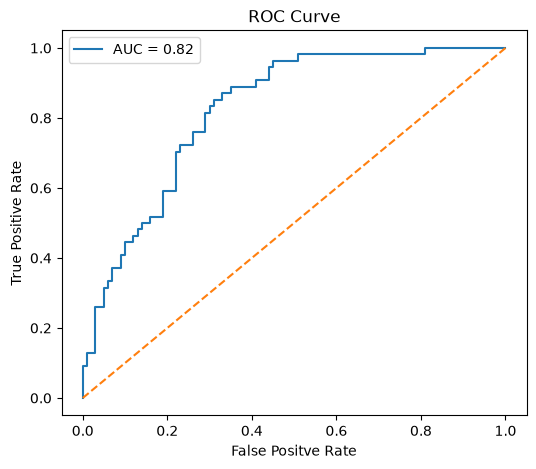

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)

print(f"ROC AUC Score: {auc_score:.3f}")

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0, 1], linestyle="--")
plt.xlabel("False Positve Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Final Notes / Summary**

In this notebook, we demonstrated the complete **classification workflow** on the Pima Indians Diabetes dataset:

- Loaded the dataset and separated **features (X)** and **target (y)**.
- Split the data into **training** and **test** sets using `train_test_split` (with `stratify=y` to preserve class balance).
- Scaled the features using **StandardScaler** (fit only on training data, then applied to test data).
- Trained a **Logistic Regression** classifier.
- Evaluated the model using:
  - **Accuracy, Precision, Recall, F1-score**
  - **Confusion Matrix** (shown as a heatmap for easy interpretation)
  - **ROC Curve and ROC-AUC** using predicted probabilities

Note: This was a **training + evaluation demo**. Deeper EDA, handling zero-as-missing values, feature engineering, and threshold tuning can be explored later.